# Indiana Pines

1. Import dependencies

In [1]:
import random
import torch
import multiprocessing
import numpy as np
import re
import time

import torch.utils.data as data

from typing import Optional, Sequence
from pathlib import Path
from typing import Callable
from dataclasses import dataclass
from typing import Any

from src.util.torch import resolve_torch_device
from src.util.hsi import (
    extract_patches,
    reduce_hsi_dim,
    preprocess_hsi,
    read_fixed_labels_mask_from_path,
    pu_bin_train_test_split_by_mask,
    PreProcessType,
    DimReductionType,
)
from src.data.indian_pines import load_indian_pines
from src.model.hsic import HyperSpectralImageClassifier
from src.visualization.plot import (
    plot_segmentation_comparison,
    plot_generic,
    plot_epoch_generic,
)
from src.data.dataset_decorator import (
    UnlabeledDatasetDecorator,
    BinaryDatasetDecorator,
    HsiMaeAdapterDatasetDecorator,
    RandomFlipDatasetDecorator
)
from src.util.reporting import (
    create_model_name,
    report_run,
    classification_trainer,
)
from src.model.representative_datapoints_search import (
    RepresentativeDataPointsSearchAdapter,
    RepresentativeDataPointsSearch,
)
from src.definitions import RAW_DATA_FOLDER, TMP_REPORTS_FOLDER
from src.util.loss import PuLoss
from src.trainer.base_trainer import (
    AdamOptimizedModule,
    BaseTrainer,
    TrainableModule,
    LrSchedulerProvider,
)
from src.util.loss import (
    logistic_loss,
)
from src.trainer.model_storage import SimpleFileBackedModelStorage
from src.model.hsimae import DualViT
from src.trainer.hsimae_trainer import DualHsiMaeTrainer

2. Prepare env

In [2]:
epoch_seconds = int(time.time())

log_dir = TMP_REPORTS_FOLDER / f"bin-mae-pu-{epoch_seconds}"

mask_dir = Path(RAW_DATA_FOLDER / "mask" / "train-test-split")

run_desc = "Bigger batch size"

In [3]:
learning_rate = 1e-3
weight_decay = 0
num_epochs = 30

In [4]:
batch_size = 256
patch_size = 9
target_dim = 75
target_class = 11
skip_maskes = 0
mask_indecies = [2, 3, 4, 5, 7, 8, 9]

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [5]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

In [6]:
torch.cuda.empty_cache()

In [7]:
torch.set_float32_matmul_precision("medium")

In [8]:
f"Device is {device}"

'Device is cuda'

3. Load dataset

In [9]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [10]:
_, image = preprocess_hsi(image, pre_process_type)

In [11]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, random_seed
)

In [12]:
x, y = extract_patches(image, labels, patch_size=patch_size)

In [13]:
num_classes = len(np.unique(y))

f"Number of classes {num_classes}"

'Number of classes 17'

In [14]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2) 
y_tensor = torch.tensor(y, dtype=torch.long)

In [15]:
cpu_count = multiprocessing.cpu_count()

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 24'

In [16]:
full_dataset = HsiMaeAdapterDatasetDecorator(data.TensorDataset(x_tensor, y_tensor))

full_loader = data.DataLoader(
    BinaryDatasetDecorator(full_dataset, target_class),
    batch_size=batch_size,
    shuffle=False,
    num_workers=cpu_count,
    persistent_workers=True,
)
predict_loader = data.DataLoader(
    UnlabeledDatasetDecorator(full_dataset),
    batch_size=batch_size,
    num_workers=cpu_count,
    persistent_workers=True,
)

4. Train model

In [17]:
def extract_prediction(y_hat):
    return (torch.sigmoid(y_hat) > 0.5).to(dtype=torch.int)

In [18]:
@dataclass
class DatapointsSearchPipeline:
    trainer: BaseTrainer
    model: TrainableModule


class IndianPinesDatapointsSearch(
    RepresentativeDataPointsSearchAdapter[DatapointsSearchPipeline]
):
    target_class: int
    skip: int
    mask_indecies: list[int]

    def __init__(self, target_class, mask_indecies, skip=0):
        super().__init__()

        self.target_class = target_class
        self.mask_indecies = mask_indecies
        self.skip = skip

    def get_run_params(
        self,
    ) -> Sequence[
        Callable[
            [], tuple[str, data.DataLoader, Optional[data.DataLoader], dict[str, Any]]
        ]
    ]:
        params = {
            "target_class": target_class,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "num_epochs": num_epochs,
            "encoder_dim": 256,
            "encoder_depth": 12,
            "decoder_dim": 64,
            "decoder_depth": 8,
            "s_depth": 9,
            "mask_ratio": 0.75,
            "b_patch_size": 5,
            "rec_loss_weight": 5,
            "pu_loss_gamma": 1.0,
            "batch_size": 256,
            "patch_size": 9,
            "target_dim": 75,
            "pre_process_type": PreProcessType.STANDARTIZATION,
            "dim_reduction_type": DimReductionType.PCA,
        }

        return [
            self.create_run_params(id, path, params)
            for id, path in self.load_partitions_by_class(self.target_class)
        ]

    def init_model(
        self, id: str, params: dict[str, Any]
    ) -> HyperSpectralImageClassifier:
        torch.cuda.empty_cache()

        positive_count = (y == target_class).sum()
        all_count = len(y)
        positive_prob = torch.tensor(positive_count / all_count, dtype=torch.float32)

        pu_loss = PuLoss(
            prior=positive_prob,
            nnpu=True,
            loss_fn=logistic_loss,
        )

        backbone = DualViT(
            img_size=params["patch_size"],
            num_class=1,
            patch_size=3,
            in_chans=1,
            bands=params["target_dim"],
            b_patch_size=params["b_patch_size"],
            embed_dim=params["encoder_dim"],
            depth=params["encoder_depth"],
            num_heads=params["encoder_dim"] // 16,
            s_depth=params["s_depth"],
            decoder_embed_dim=params["decoder_dim"],
            decoder_depth=params["decoder_depth"],
            decoder_num_heads=params["decoder_dim"] // 8,
            norm_pix_loss=True,
            trunc_init=True,
        )
        model = AdamOptimizedModule(
            net=backbone,
            lr=params["learning_rate"],
            weight_decay=params["weight_decay"],
            scheduler=LrSchedulerProvider(
                t_initial=params["num_epochs"],
                lr_min=1e-6,
                warmup_t=int(np.ceil(0.1 * params["num_epochs"])),
                warmup_lr_init=params["learning_rate"] * 0.01,
            ),
        ).to(device)

        trainer = DualHsiMaeTrainer(
            epochs=params["num_epochs"],
            loss_fun=pu_loss,
            mask_ratio=params["mask_ratio"],
            num_classes=2,
            rec_loss_weight=params["rec_loss_weight"],
            device=device,
            extract_prediction=extract_prediction,
            model_storage=SimpleFileBackedModelStorage(
                "eval_kappa",
                f"indian_pines_bin_hsimae_pu_{target_class}_{id}",
            ),
        )

        return DatapointsSearchPipeline(trainer=trainer, model=model)

    def fit_model(
        self,
        model: DatapointsSearchPipeline,
        train_loader: data.DataLoader,
        eval_loader: Optional[data.DataLoader],
        params: dict[str, Any],
    ) -> list[dict[str, float]]:
        feedback, trained_model = model.trainer.fit(
            model=model.model,
            train_dataloader=train_loader,
            eval_dataloader=eval_loader,
        )

        model.model = trained_model

        return [it.eval for it in feedback.history]

    def score_model(self, model: DatapointsSearchPipeline) -> dict[str, float]:
        trainer = model.trainer

        return trainer.validate(model.model, full_loader)

    def on_scored_model(
        self,
        id: str,
        params: dict[str, float],
        model: DatapointsSearchPipeline,
        model_history: list[dict[str, float]],
        score: dict[str, float],
    ):
        trainer = model.trainer
        model = model.model

        if model_history:
            losses = [it["eval_loss"] for it in model_history]
            kappas = [it["eval_kappa"] for it in model_history]
            plot_epoch_generic(
                losses, desc=f"Loss for class {self.target_class} ({id} examples)"
            )
            plot_epoch_generic(
                kappas, desc=f"Kappa for class {self.target_class} ({id} examples)"
            )

        y_pred = trainer.predict(model, predict_loader)[1]
        y_pred = torch.cat(y_pred, dim=0)
        y_pred = extract_prediction(y_pred)
        y_pred = y_pred.reshape(image_h, image_w)
        y_pred = y_pred.cpu()

        plot_segmentation_comparison(
            y.reshape(image_h, image_w) == self.target_class, y_pred.numpy()
        )

        model_name = create_model_name(f"indian_pines_", {target_class: id})
        model_category = "hsimae-pu"

        run_params = {
            **params,
            "batch_size": batch_size,
            "patch_size": patch_size,
            "target_dim": target_dim,
            "pre_process_type": str(pre_process_type),
            "dim_reduction_type": str(dim_reduction_type),
        }

        report_run(
            model_name=model_name,
            model_category=model_category,
            run_desc=run_desc,
            run_params=run_params | model.get_params() | trainer.get_params(),
            run_metrics=classification_trainer(score),
        )

    def load_partitions_by_class(self, clazz: int) -> list[tuple[str, Path]]:
        mask_arr = [
            (re.search(r"-(\d+)\.npy$", str(fn)).group(1), fn)
            for fn in mask_dir.glob(f"indian-pines-train-test-split-{clazz}-*.npy")
        ]

        mask_arr = sorted(list(set(mask_arr)), key=lambda it: int(it[0]))
        mask_arr = [mask_arr[i] for i in self.mask_indecies]

        return mask_arr[skip_maskes:]

    def create_dataloader_from_mask_file(
        self, path: Path
    ) -> tuple[data.DataLoader, data.DataLoader]:
        mask = read_fixed_labels_mask_from_path(path)

        x_train, y_train, _, _ = pu_bin_train_test_split_by_mask(
            self.target_class, x, y, mask
        )

        x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
        x_test_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
        y_test_tensor = torch.tensor(y == self.target_class, dtype=torch.float32)

        train_dataset = RandomFlipDatasetDecorator(
            data.TensorDataset(x_train_tensor, y_train_tensor)
        )
        test_dataset = data.TensorDataset(x_test_tensor, y_test_tensor)

        train_loader = data.DataLoader(
            HsiMaeAdapterDatasetDecorator(train_dataset),
            batch_size=batch_size,
            shuffle=True,
            num_workers=cpu_count,
            persistent_workers=True,
        )
        test_loader = data.DataLoader(
            HsiMaeAdapterDatasetDecorator(test_dataset),
            batch_size=batch_size,
            shuffle=False,
            num_workers=cpu_count,
            persistent_workers=True,
        )

        return train_loader, test_loader

    def create_run_params(
        self, id: str, path: Path, params: dict[str, float]
    ) -> Callable[
        [], tuple[str, data.DataLoader, Optional[data.DataLoader], dict[str, float]]
    ]:
        def curryng():
            loader, eval_loader = self.create_dataloader_from_mask_file(path)

            return id, loader, eval_loader, params

        return curryng

  0%|          | 0/7 [00:00<?, ?it/s]

img_size (9, 9) patch_size (3, 3) bands 75 b_patch_size 5
model initialized


  0%|          | 0/30 [00:00<?, ?it/s]

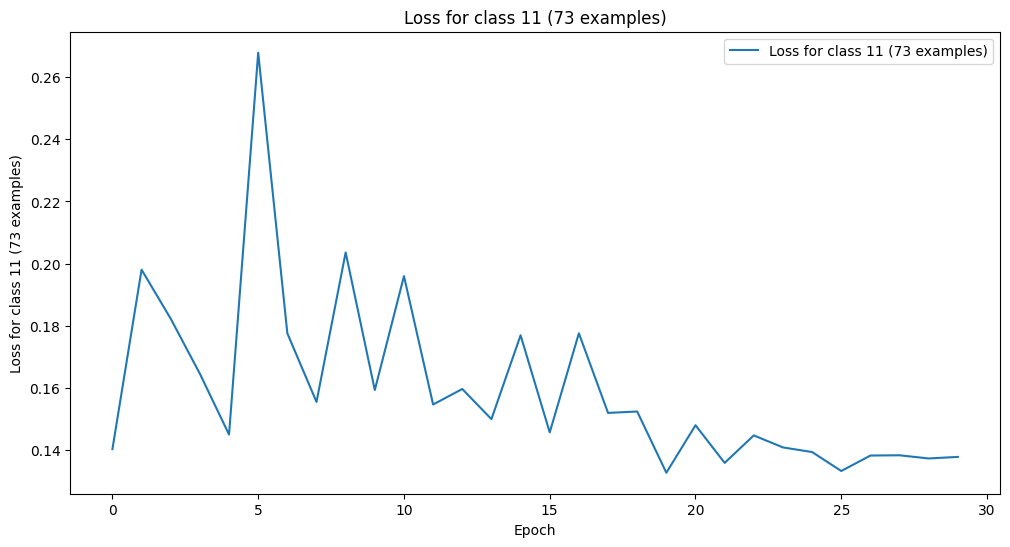

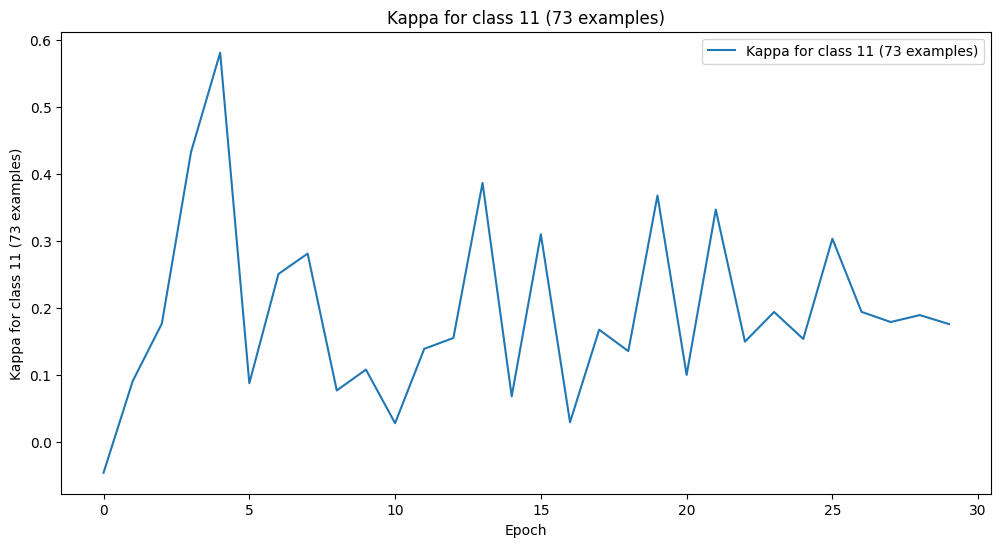

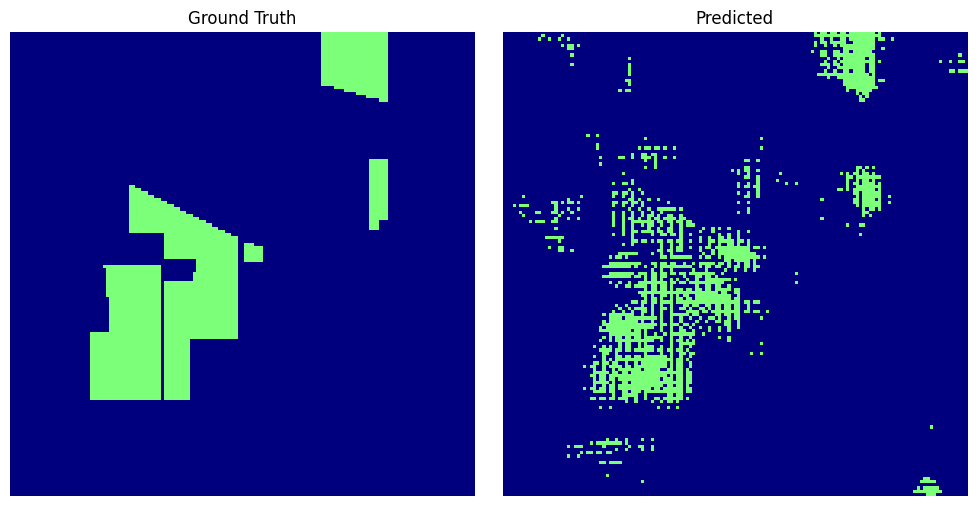

 14%|█▍        | 1/7 [3:23:07<20:18:44, 12187.35s/it, eval_accuracy_avg=0.923, eval_accuracy_overall=0.76, eval_f1=0.918, eval_kappa=0.581, eval_loss=0.145, id=73]

img_size (9, 9) patch_size (3, 3) bands 75 b_patch_size 5
model initialized


  0%|          | 0/30 [00:00<?, ?it/s]

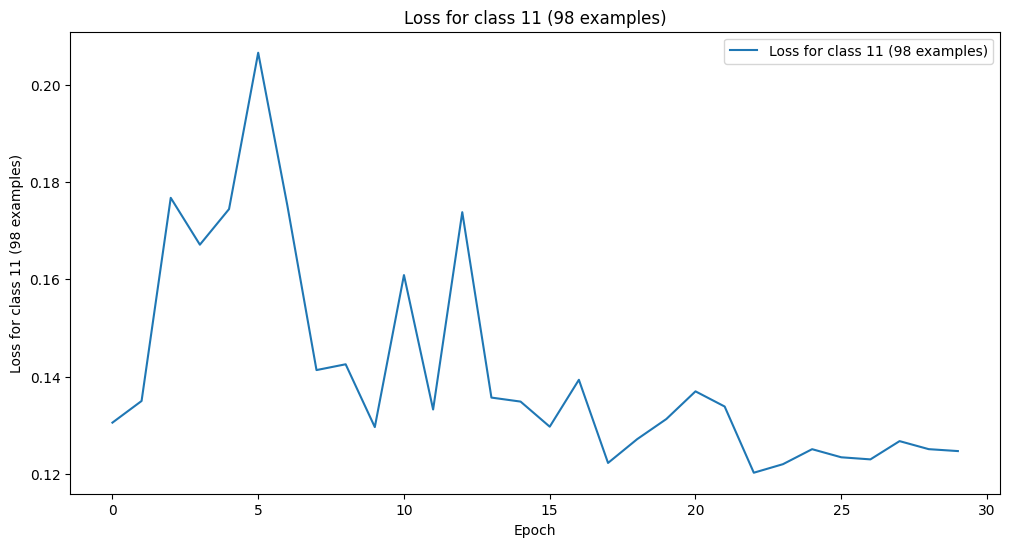

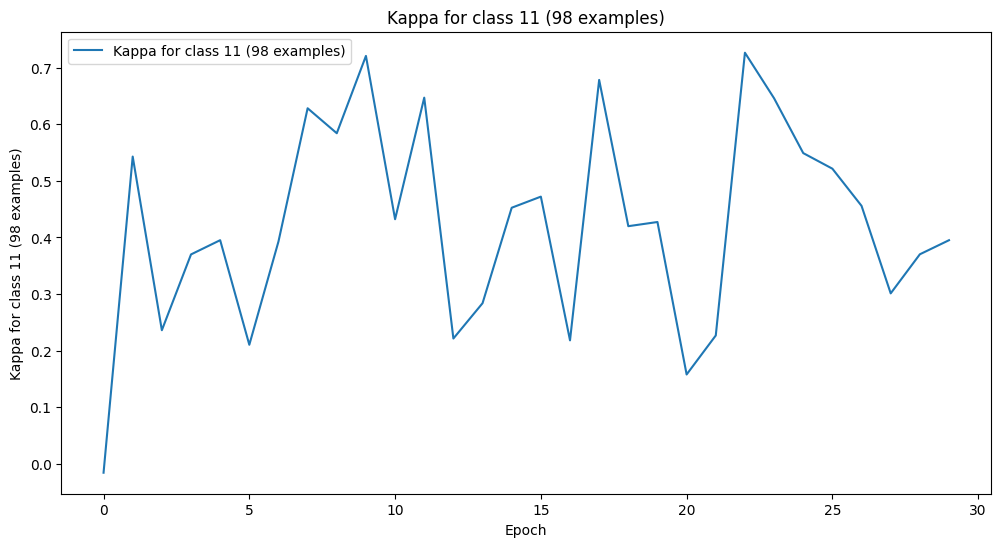

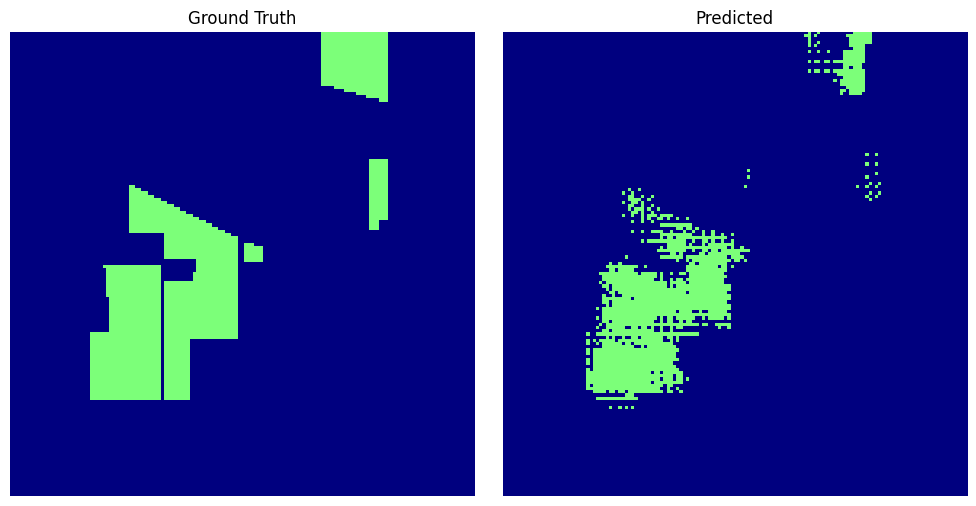

 29%|██▊       | 2/7 [6:51:42<17:11:41, 12380.22s/it, eval_accuracy_avg=0.952, eval_accuracy_overall=0.81, eval_f1=0.947, eval_kappa=0.726, eval_loss=0.12, id=98] 

img_size (9, 9) patch_size (3, 3) bands 75 b_patch_size 5
model initialized


  0%|          | 0/30 [00:00<?, ?it/s]

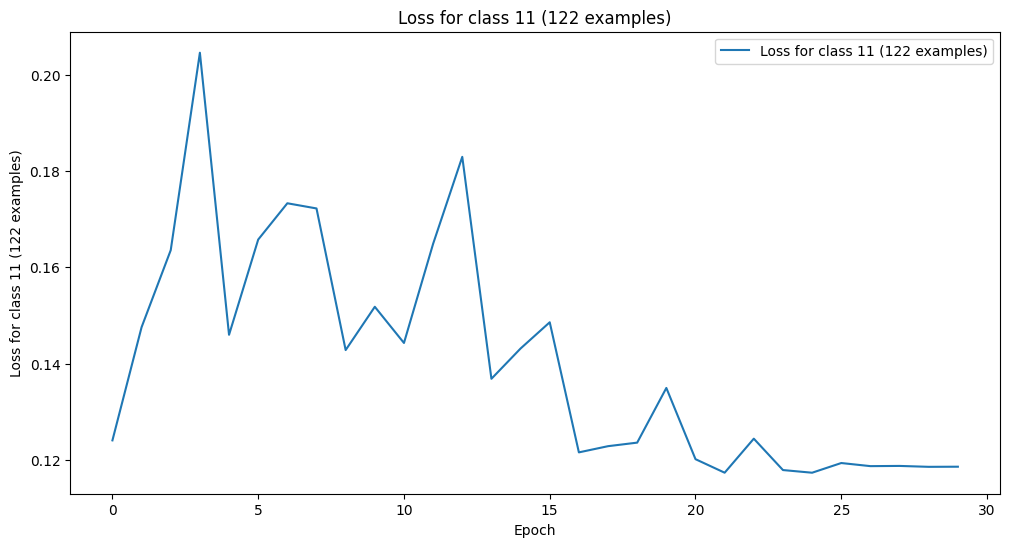

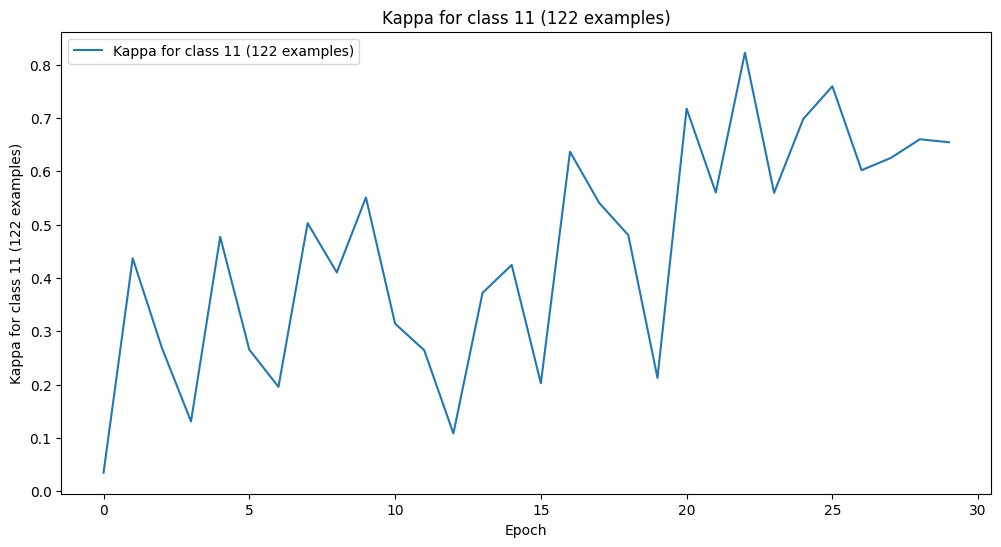

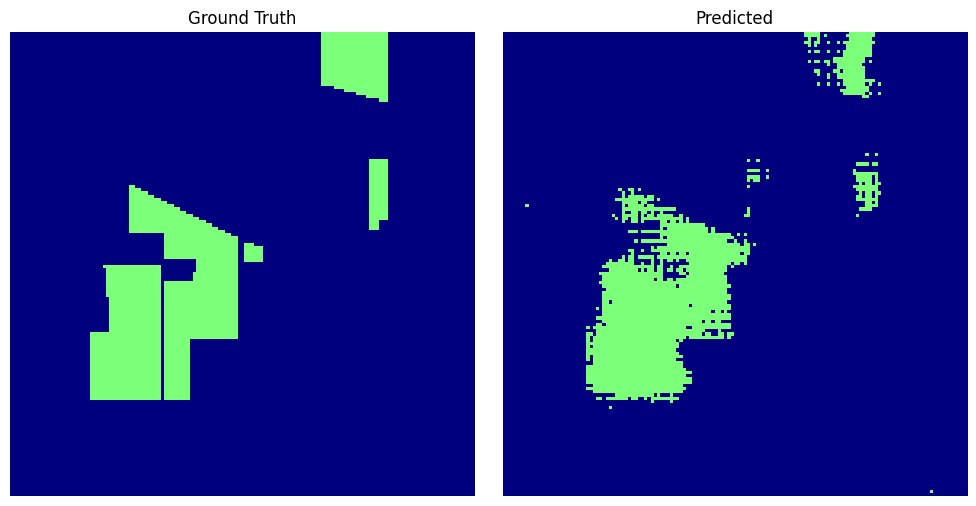

 43%|████▎     | 3/7 [10:49:39<14:43:05, 13246.36s/it, eval_accuracy_avg=0.965, eval_accuracy_overall=0.892, eval_f1=0.964, eval_kappa=0.822, eval_loss=0.124, id=122]

img_size (9, 9) patch_size (3, 3) bands 75 b_patch_size 5
model initialized


  0%|          | 0/30 [00:00<?, ?it/s]

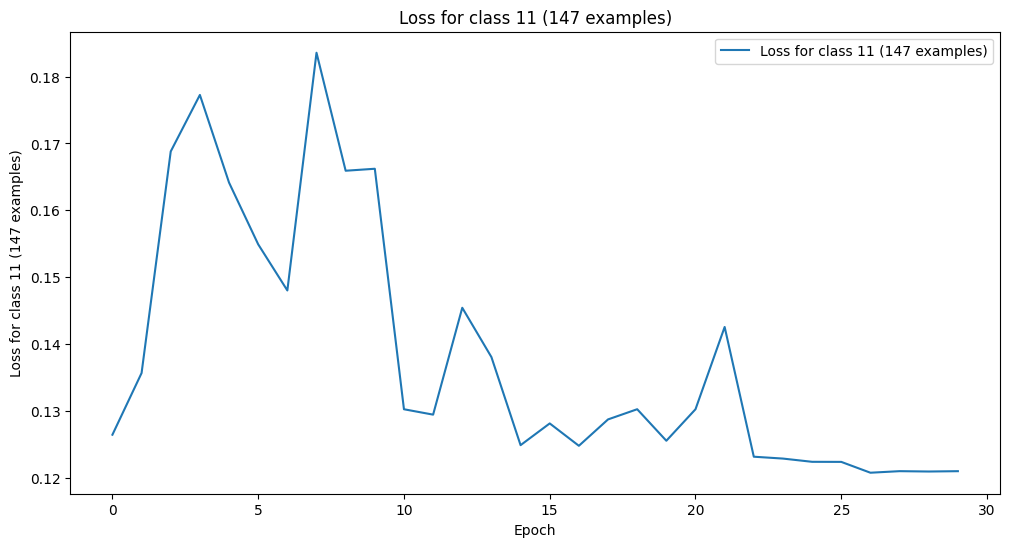

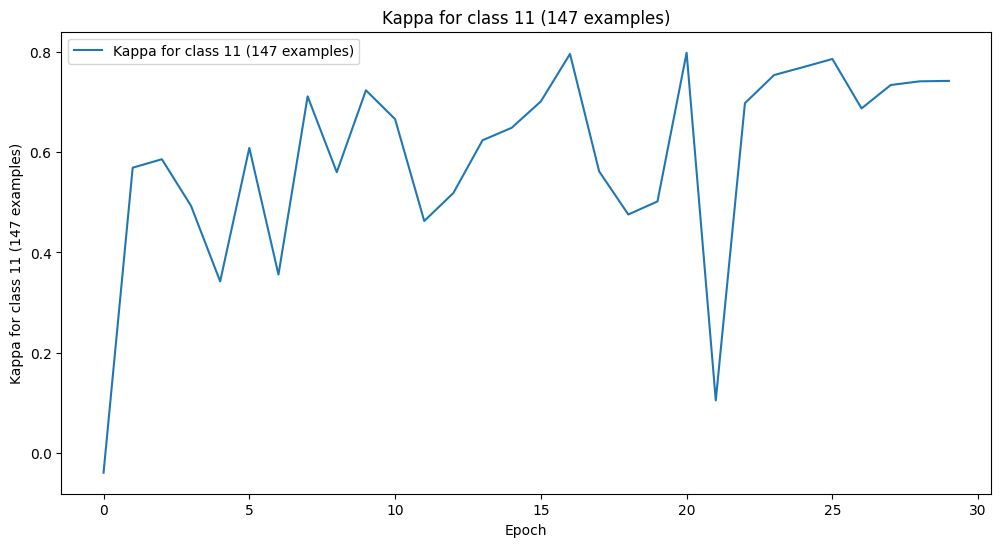

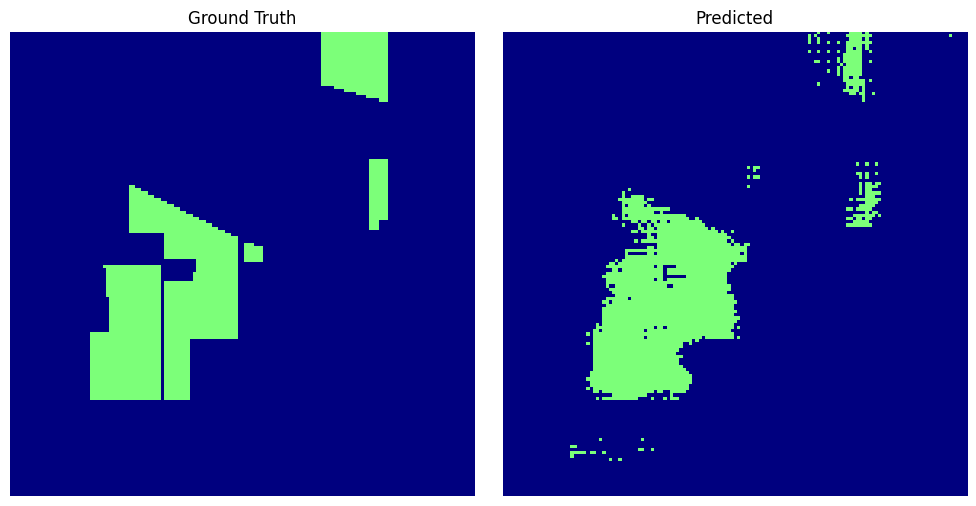

 57%|█████▋    | 4/7 [15:16:38<11:57:03, 14341.01s/it, eval_accuracy_avg=0.96, eval_accuracy_overall=0.881, eval_f1=0.959, eval_kappa=0.799, eval_loss=0.13, id=147]  

img_size (9, 9) patch_size (3, 3) bands 75 b_patch_size 5
model initialized


  0%|          | 0/30 [00:00<?, ?it/s]

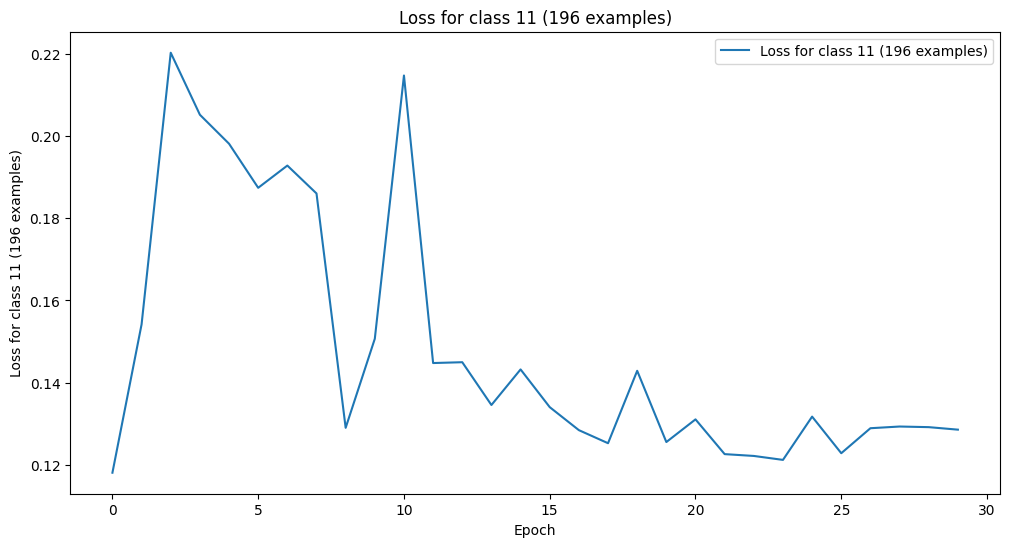

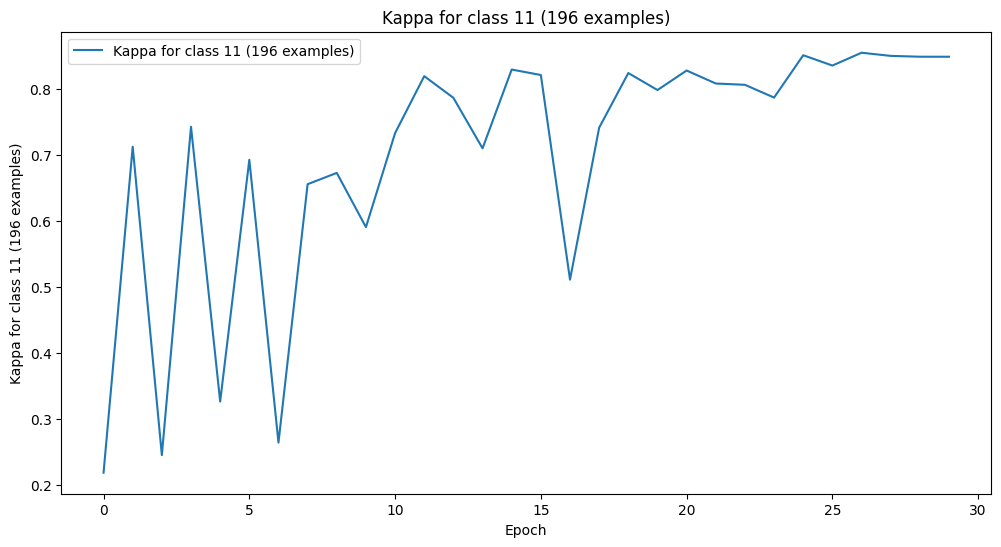

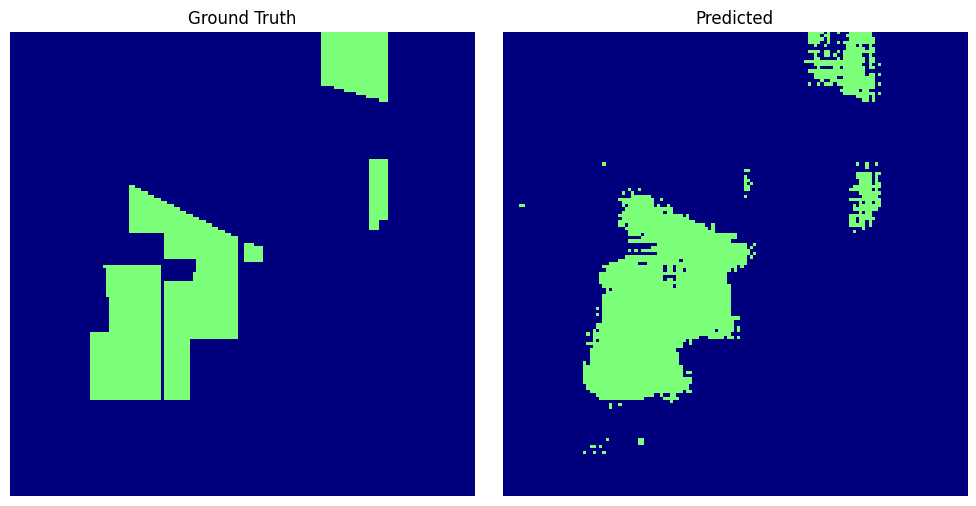

 71%|███████▏  | 5/7 [20:35:38<8:55:43, 16071.57s/it, eval_accuracy_avg=0.97, eval_accuracy_overall=0.93, eval_f1=0.97, eval_kappa=0.856, eval_loss=0.129, id=196]  

img_size (9, 9) patch_size (3, 3) bands 75 b_patch_size 5
model initialized


  0%|          | 0/30 [00:00<?, ?it/s]

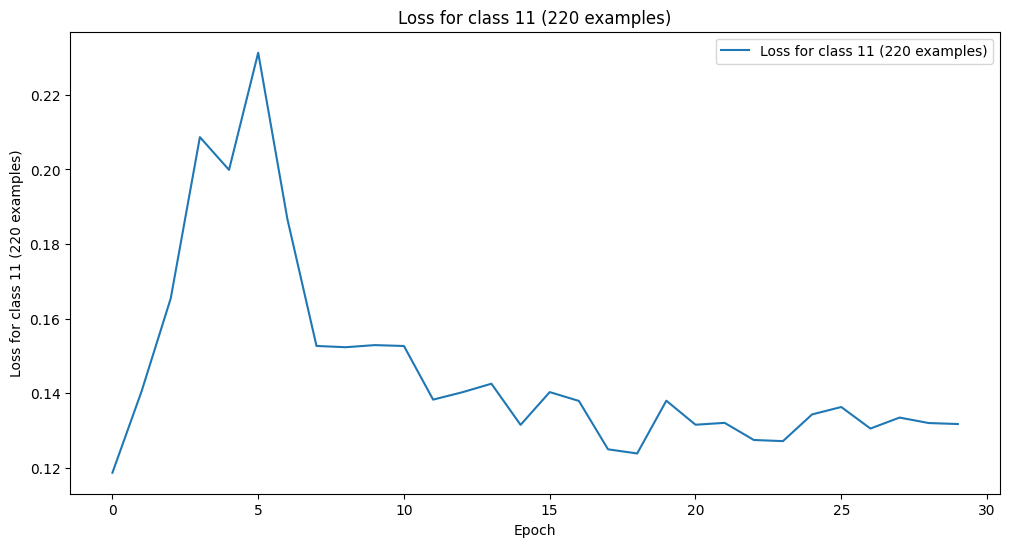

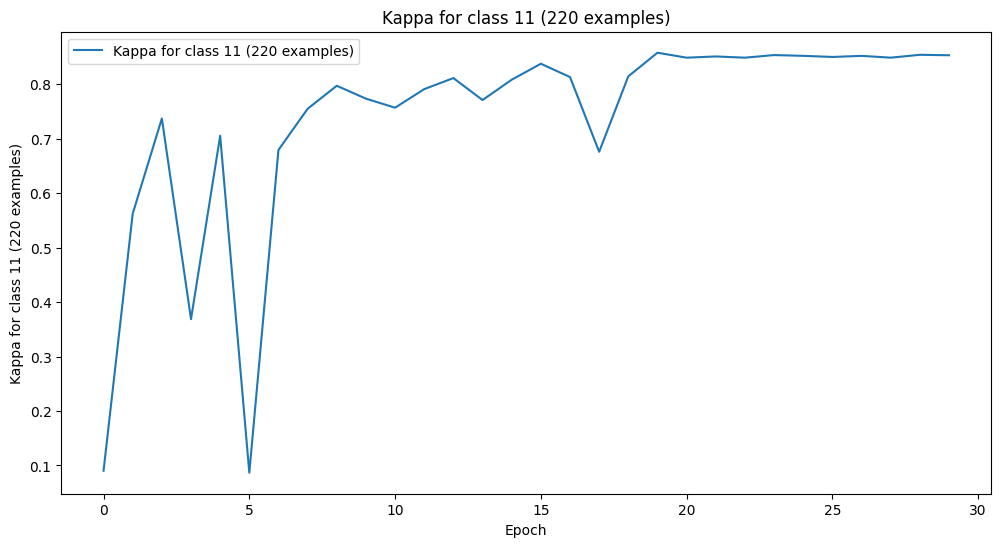

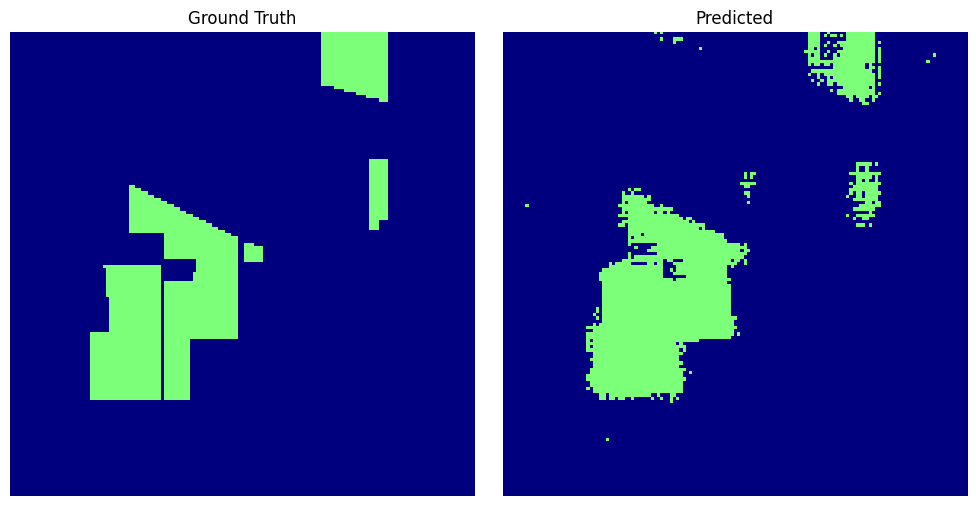

 86%|████████▌ | 6/7 [26:39:25<5:00:28, 18028.18s/it, eval_accuracy_avg=0.971, eval_accuracy_overall=0.928, eval_f1=0.971, eval_kappa=0.858, eval_loss=0.138, id=220]

img_size (9, 9) patch_size (3, 3) bands 75 b_patch_size 5
model initialized


  0%|          | 0/30 [00:00<?, ?it/s]

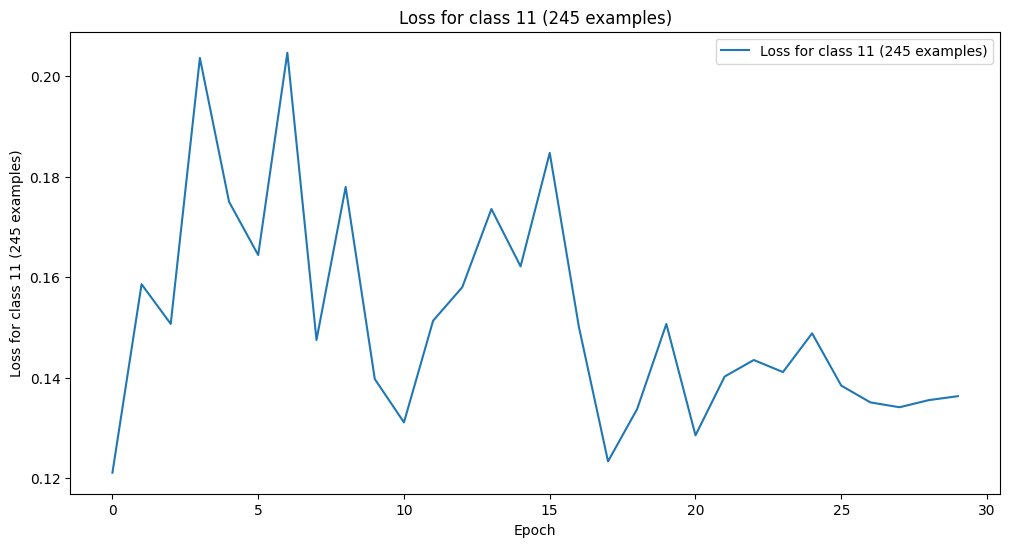

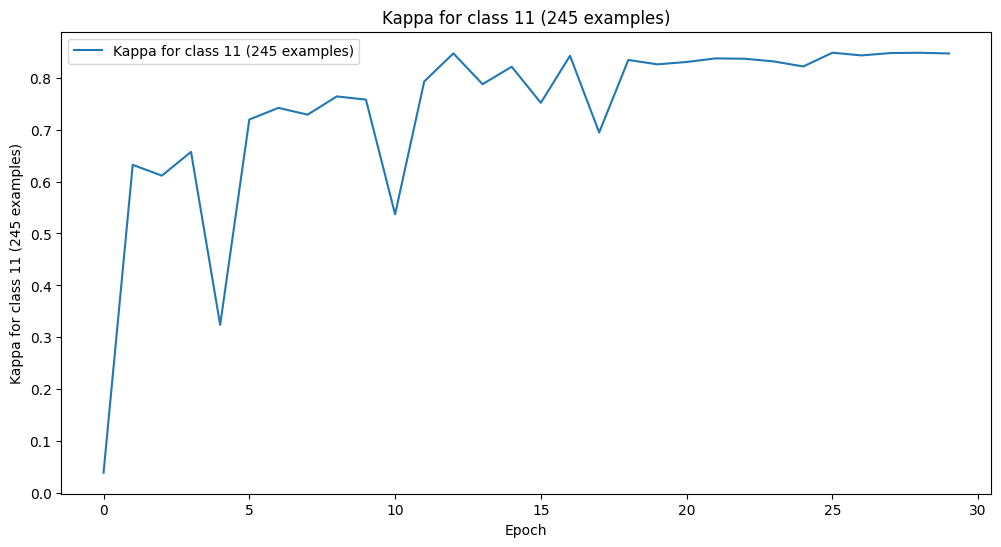

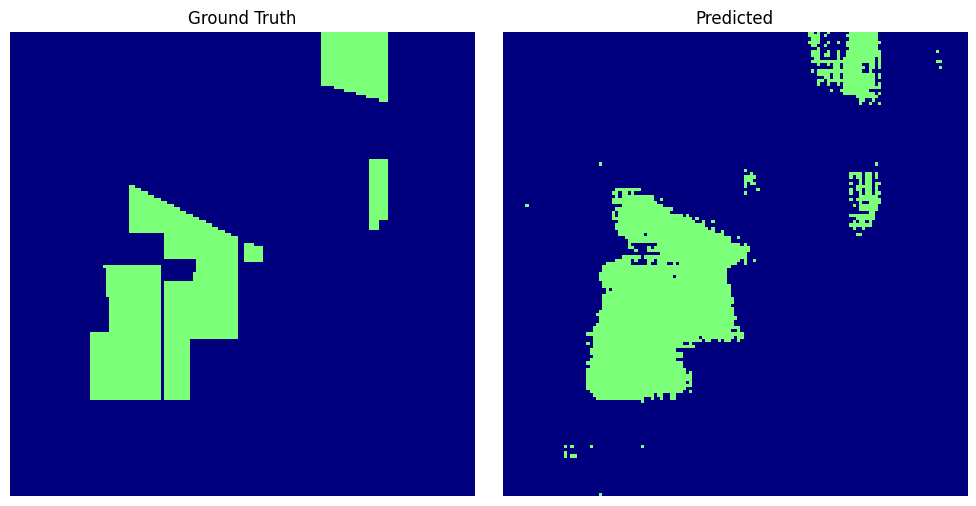

100%|██████████| 7/7 [32:37:09<00:00, 16775.59s/it, eval_accuracy_avg=0.968, eval_accuracy_overall=0.931, eval_f1=0.968, eval_kappa=0.848, eval_loss=0.138, id=245]  


In [19]:
search = RepresentativeDataPointsSearch(
    IndianPinesDatapointsSearch(
        target_class, mask_indecies=mask_indecies, skip=skip_maskes
    ),
    log_dir,
    f"class-{target_class}",
)

feedback = search.run()

In [20]:
feedback[1]

HistoryEntry(id='98', score={'eval_f1': 0.9474645853042603, 'eval_accuracy_overall': 0.8101232051849365, 'eval_accuracy_avg': 0.9518192410469055, 'eval_kappa': 0.7264240980148315, 'eval_loss': 0.1202216387154108})

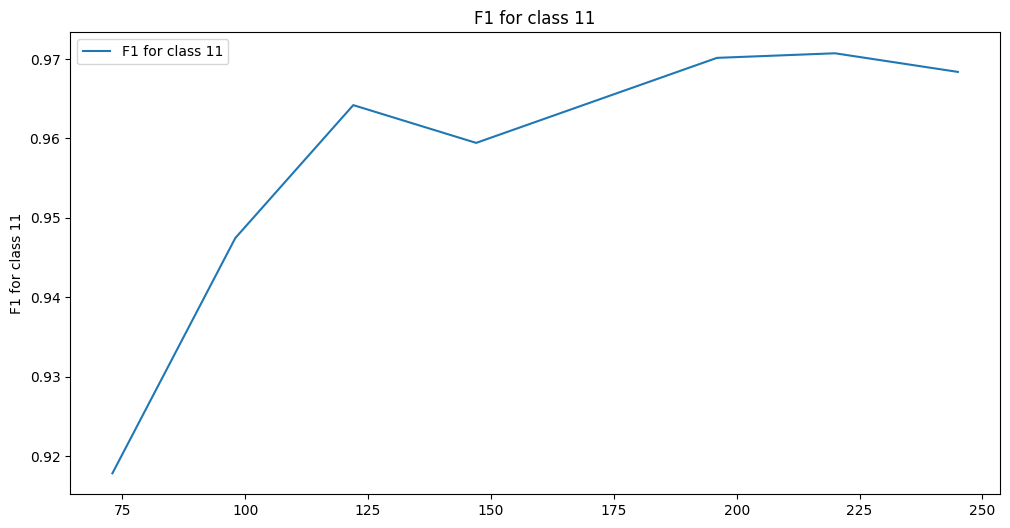

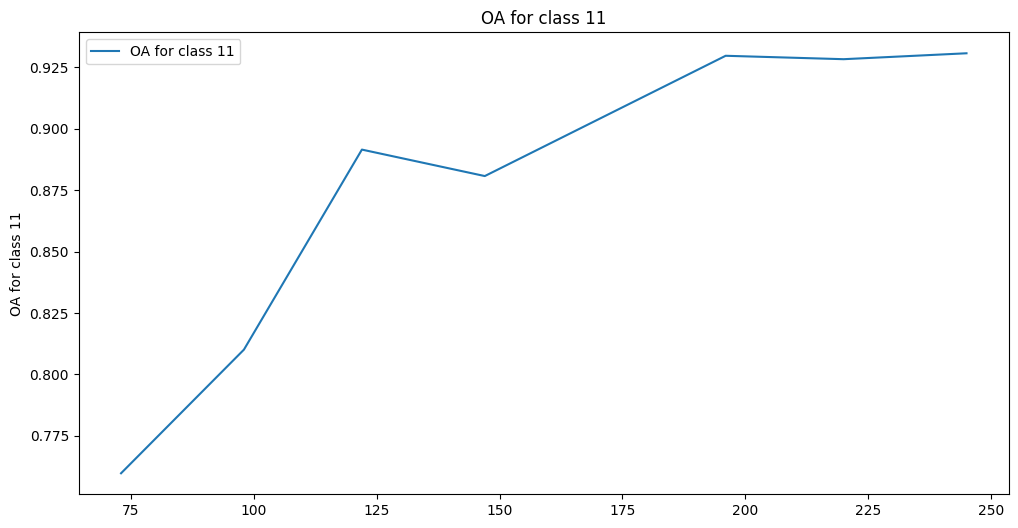

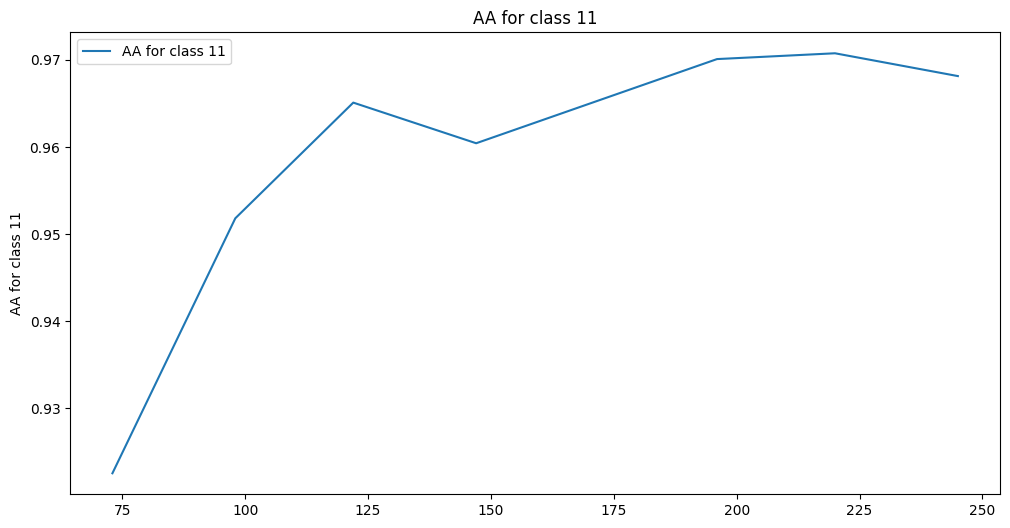

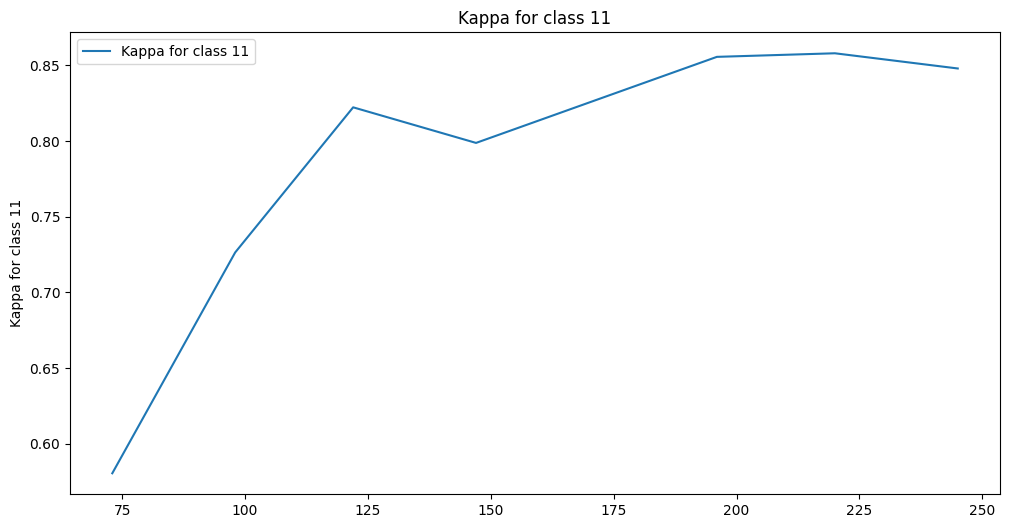

In [21]:
ids = [int(it.id) for it in feedback]
f1s = [it.score["eval_f1"] for it in feedback]
oas = [it.score["eval_accuracy_overall"] for it in feedback]
aas = [it.score["eval_accuracy_avg"] for it in feedback]
kappas = [it.score["eval_kappa"] for it in feedback]

plot_generic(ids, f1s, desc=f"F1 for class {target_class}")
plot_generic(ids, oas, desc=f"OA for class {target_class}")
plot_generic(ids, aas, desc=f"AA for class {target_class}")
plot_generic(ids, kappas, desc=f"Kappa for class {target_class}")